# Single-extracellular-vesicle (single-EV) proteomics

Extracellular vesicles (EVs) — exosomes and microvesicles — are nanoscale
membrane particles that every cell releases into its surroundings. They
carry a surface-protein cargo that reflects their cell of origin, and they
are intense biomarker candidates for liquid biopsy. Until recently EV
proteomics was almost always **bulk**: a preparation of millions of
vesicles was lysed and measured together, giving one averaged protein
profile. That average hides the central fact about EVs — a preparation is
a *mixture of vesicle subpopulations*, and a bulk measurement can never
tell you whether two markers are on the **same** vesicle or merely in the
same tube.

**Single-EV proteomics** measures the protein content of *individual*
vesicles. The natural data structure is an **EV x protein matrix** — each
row one vesicle, each column one protein/marker target — which is
structurally identical to a single-cell *cell x gene* matrix (a vesicle
plays the role of a cell, a protein marker the role of a gene). The entire
single-cell analysis stack therefore transfers: QC, normalization,
dimensionality reduction, subpopulation clustering, marker discovery and
differential analysis.

`ov.single.ev` is the omicverse module for this modality. It implements the
full single-EV pipeline behind one API and supports three measurement
value types — sequencing **counts**, imaging/flow **intensity** and digital
**binary** calls — so the same functions work whatever the platform.

This notebook runs the **comprehensive** pipeline on real
sequencing-count data: the **Proximity Barcoding Assay** (PBA) of
Wu *et al.*, *Nat Commun* 2019 (10:3854; PMID 31477692), which barcodes
individual exosomes and reads out their surface proteins by
next-generation sequencing. Analysis follows the **MISEV2023** minimal-
information framework (Welsh *et al.*, *J Extracell Vesicles* 2024).


## 1. Load the data and inspect it

`ov.datasets.ev_pba()` downloads the real PBA dataset — a curated
75,000-EV x 40-surface-protein tutorial subset spanning 15 samples: 13
cancer/normal cell-line exosome populations and 2 human-serum exosome
samples. Each row is one individual exosome (a PBA complex identified by
its barcode); each value is a sequencing read count for one
surface-protein antibody. The measurement value type is recorded in
`uns['ev']['value_type']` — here `'count'`.


In [1]:
import omicverse as ov
import matplotlib.pyplot as plt

ov.plot_set(font_path='Arial')
adata = ov.datasets.ev_pba()
adata

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

🔍 Downloading data to ./data/ev_pba.h5ad
⚠️ File ./data/ev_pba.h5ad already exists


AnnData object with n_obs × n_vars = 75000 × 40
    obs: 'sample', 'source', 'sample_type', 'condition', 'complex_tag', 'total_counts', 'n_proteins'
    uns: 'ev'

In [2]:
# the per-EV metadata: sample, biological source, cancer/normal condition
adata.obs[['sample', 'source', 'sample_type', 'condition']].head()

,sample,source,sample_type,condition
ev_id,,,,
A549|TCCTGTTGCTAGTGT,A549,lung adenocarcinoma,cell_line,cancer
A549|ATCTAAAAAATACAG,A549,lung adenocarcinoma,cell_line,cancer
A549|GAGCGGTCACATCAA,A549,lung adenocarcinoma,cell_line,cancer
A549|ATAATATTTAGCTTA,A549,lung adenocarcinoma,cell_line,cancer
A549|AGCTAACCTTCGGCC,A549,lung adenocarcinoma,cell_line,cancer


In [3]:
# how many individual exosomes per sample, and the measurement value type
print(adata.obs['sample'].value_counts())
print()
print('value type :', adata.uns['ev']['value_type'])
print('assay      :', adata.uns['ev']['assay'])

sample
A549       5000
AGS        5000
BLC21      5000
Daudi      5000
HCT116     5000
HEK293     5000
K562       5000
MKN45      5000
MKN7       5000
MM1        5000
PC3        5000
SK-N-SH    5000
Serum-1    5000
Serum-2    5000
U87MG      5000
Name: count, dtype: int64

value type : count
assay      : Proximity Barcoding Assay


## 2. Quality control

Single-EV QC targets artifacts that are specific to vesicle data, not cell
data. `ov.single.ev.qc` removes EVs with too few detected proteins
(membrane fragments, free antibody, background), removes or caps EVs with
implausibly high total signal (doublets / barcode collisions where two
vesicles are read as one tag) and drops proteins detected in too few EVs.
Here we require at least 2 detected proteins per EV and keep proteins
present in at least 0.5% of vesicles.


In [4]:
adata = ov.single.ev.qc(adata, min_proteins=2, min_ev_frac=0.005)
qc = adata.uns['ev']['qc']
print(f"EVs: {qc['n_ev_in']:,} -> {qc['n_ev_out']:,} "
      f"({qc['n_ev_removed']:,} removed)")
print(f"proteins: {qc['n_proteins_in']} -> {qc['n_proteins_out']}")
print(f"high-signal (doublet) cut: {qc['high_signal_cut']:.1f}")

EVs: 75,000 -> 46,839 (28,161 removed)
proteins: 40 -> 40
high-signal (doublet) cut: 19.8


About 28,000 low-information EVs (membrane fragments / barcodes with too
few reads) are removed, leaving ~47,000 informative exosomes — a typical
attrition for sparse single-EV sequencing data. The PBA panel is small (40
antibodies) so all 40 proteins are retained.

A MISEV2023 *purity* assessment quantifies co-isolated non-vesicular
contaminants — lipoproteins (ApoA1/ApoB), albumin, organelle proteins.
`contaminant_score` writes per-EV scores and a preparation-level summary.


In [5]:
adata = ov.single.ev.contaminant_score(adata)
contam = adata.uns['ev']['contaminant']
print('preparation purity :', round(contam['purity'], 3))
print('contaminant markers found :', contam['markers_found'])

preparation purity : 1.0
contaminant markers found : {'lipoprotein': [], 'albumin': [], 'organelle': []}


The purity score is 1.0 and no contaminant markers were found — the PBA
panel was deliberately designed from tetraspanins, integrins and other
genuine EV surface proteins, so it contains no lipoprotein/albumin/
organelle targets to begin with. This is honest: purity here reflects
panel design, not a contaminant-free preparation per se.

Before normalizing, we take a MISEV-style snapshot of the raw counts with
`ev_summary` — once `normalize` overwrites `X`, the raw per-EV totals are
no longer in `X` (they remain in `layers['counts']`).


In [6]:
ov.single.ev.ev_summary(adata, cluster_key=None)

,n_evs,n_proteins,n_subpopulations,n_samples,value_type,platform,mean_proteins_per_ev,median_total_signal,qc_pass_rate
0,46839,40,0,15,count,unknown,3.368368,5.0,1.0


## 3. Source x protein abundance — reproducing PBA Fig. 4a

The original PBA study (Wu *et al.*, *Nat Commun* 2019, **Fig. 4a**) opens
its biological analysis with a **source x protein abundance heatmap**: the
per-EV molecule counts are aggregated to the level of each *source* (the
13 cell lines plus 2 human-serum samples) and shown as
`log(moleculeTag+1)`, rows = sources, columns = antibody targets. It is
the *pseudobulk* view of single-EV data — collapse the millions of
vesicles back to one profile per source and ask **which source carries
which surface protein**.

We reproduce it directly. `ov.single.ev.pseudobulk` aggregates the QC'd
per-EV matrix to a 15-source x 40-protein matrix; we `log1p` it and draw
the sample x protein heatmap with the generic `ov.pl.group_heatmap`. This
is the bulk-level summary that *precedes* the single-vesicle analysis —
the rest of the notebook then goes beyond it.

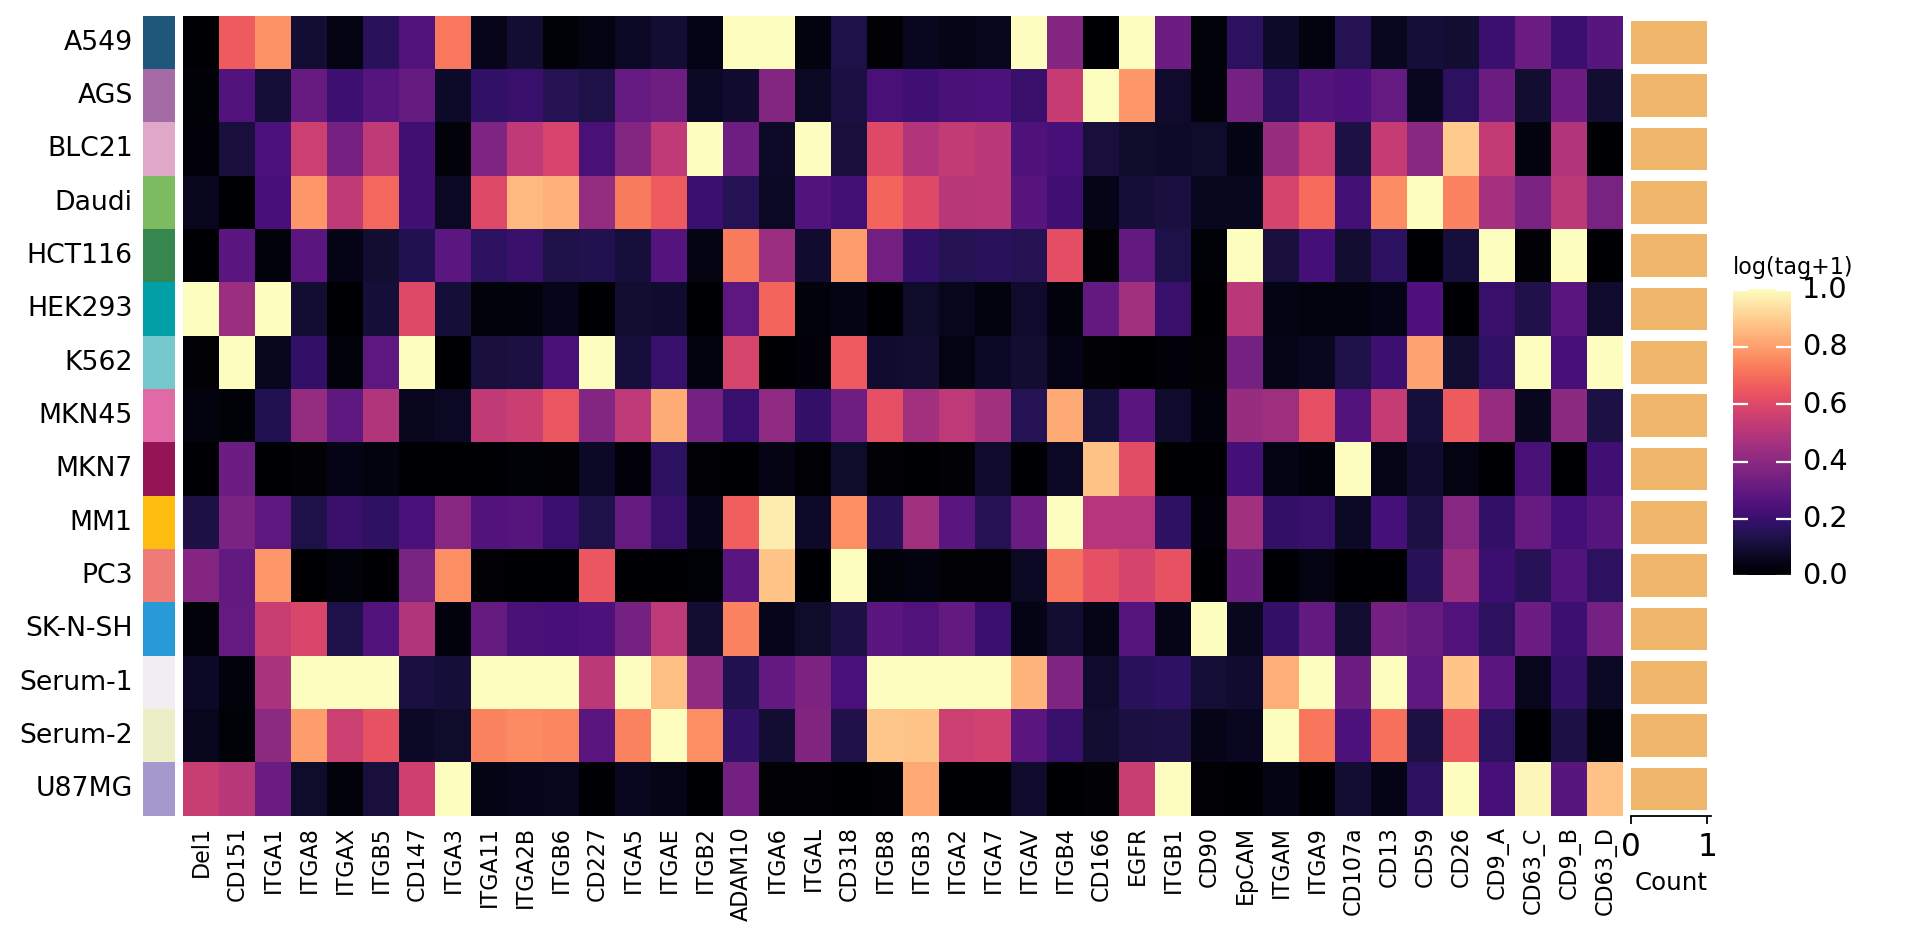

In [7]:
# PBA Fig. 4a: aggregate per-EV counts to a source x protein matrix
pb_src = ov.single.ev.pseudobulk(adata, sample_key='sample', mode='mean')
pb_src.X = ov.np.log1p(pb_src.X)            # log(moleculeTag+1), as in Fig. 4a
pb_src.obs['sample'] = pb_src.obs.index.astype('category')
ov.pl.group_heatmap(pb_src, var_names=list(pb_src.var_names), groupby='sample',
                    standard_scale='var', cmap='magma', figsize=(9, 5),
                    label='log(tag+1)')
plt.show()

## 4. Normalization

The normalization step is the one place the single-cell stack must branch
on the assay's value type, so `ov.single.ev.normalize` is EV-specific. PBA
produces **sequencing counts**, so the right transform is the
**centered-log-ratio** (CLR) — the same transform CITE-seq uses for
antibody-derived tags. CLR removes the per-EV composition/depth effect by
dividing through the per-vesicle geometric mean. `method='auto'` reads
`uns['ev']['value_type']` and picks CLR automatically for count data. We
normalize the **full QC'd set** here — CLR is a per-vesicle transform — so
that the stratified embedding in Section 5 and every downstream subset
share one consistent normalization.

In [8]:
# normalize the full QC'd set (CLR is a per-vesicle transform)
ov.single.ev.normalize(adata, method='auto')
print('normalization method :', adata.uns['ev']['normalize']['method'])
print('value type           :', adata.uns['ev']['value_type'])

normalization method : clr
value type           : count


## 5. Stratified embedding — reproducing PBA Fig. 4b

PBA data is exceptionally sparse: most vesicles carry just 1-2 detected
proteins. EVs with so few detected proteins share near-identical
presence/absence patterns and cannot be resolved by source.

The original PBA study (Wu *et al.*, *Nat Commun* 2019, **Fig. 4b**)
addressed this with **three t-SNE panels side by side** — exosomes with
**1**, **2**, and **>=3** detected proteins — each coloured by source. The
finding: 1-protein exosomes give *no good distinction between sources* (a
radial "firework" sparsity artifact), 2-protein exosomes are still
ambiguous, and **only the >=3-protein subset** resolves same-source
exosomes into coherent regions. The paper used t-SNE and did not attempt
formal clustering on the sparse data.

We reproduce all three panels faithfully. The Section-2 QC kept only EVs
with **>=2** detected proteins, so to recover the 1-protein stratum we
apply a permissive QC (`min_proteins=1`) to a fresh copy of the data,
normalize it, and split on `obs['n_proteins']` into the 1 / 2 / >=3
strata. Each stratum is z-scored (`ov.pp.scale`), reduced (`ov.pp.pca`,
small panel so a low `n_pcs`) and embedded with **t-SNE** (`ov.pp.tsne`,
as in the paper). The three embeddings are then drawn together, coloured
by `source`. This section both reproduces Fig. 4b *and* motivates running
the rest of the pipeline on the informative **>=3-protein subset** of the
standard (`min_proteins=2`) QC'd data.

In [9]:
# permissive QC on a fresh copy recovers the 1-protein EVs for Fig. 4b
viz = ov.single.ev.qc(ov.datasets.ev_pba(), min_proteins=1, min_ev_frac=0.005)
ov.single.ev.normalize(viz, method='auto')
ev1 = viz[viz.obs['n_proteins'] == 1].copy()
ev2 = viz[viz.obs['n_proteins'] == 2].copy()
ev3 = viz[viz.obs['n_proteins'] >= 3].copy()
print(f"1-protein: {ev1.n_obs:,}   2-protein: {ev2.n_obs:,}   "
      f">=3-protein: {ev3.n_obs:,}  of {viz.n_obs:,} EVs")

🔍 Downloading data to ./data/ev_pba.h5ad
⚠️ File ./data/ev_pba.h5ad already exists


1-protein: 21,776   2-protein: 17,781   >=3-protein: 29,058  of 68,615 EVs


In [10]:
# Fig. 4b panel 1: embed the 1-detected-protein stratum (scale -> PCA -> t-SNE)
ov.pp.scale(ev1, max_value=10, layers_add='scaled')
ov.pp.pca(ev1, layer='scaled', n_pcs=30)
ov.pp.tsne(ev1, use_rep='scaled|original|X_pca', n_pcs=30)


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.0331s                                                 │
│  Shape:    21,776 x 40 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ status                                               │
│           │ ✚ status_args                                          │
│                                                                    │
│  ● LAYERS │ ✚ scaled (array, 21776x40)                             │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
compu


╭─ SUMMARY: tsne ────────────────────────────────────────────────────╮
│  Duration: 41.2834s                                                │
│  Shape:    21,776 x 40 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ tsne                                                 │
│           │ └─ params: {'n_components': 2, 'perplexity': 30, 'early_ex...│
│                                                                    │
│  ● OBSM   │ ✚ X_tsne (array, 21776x2)                              │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


In [11]:
# Fig. 4b panel 2: embed the 2-detected-protein stratum
ov.pp.scale(ev2, max_value=10, layers_add='scaled')
ov.pp.pca(ev2, layer='scaled', n_pcs=30)
ov.pp.tsne(ev2, use_rep='scaled|original|X_pca', n_pcs=30)


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.0135s                                                 │
│  Shape:    17,781 x 40 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ status                                               │
│           │ ✚ status_args                                          │
│                                                                    │
│  ● LAYERS │ ✚ scaled (array, 17781x40)                             │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
compu


╭─ SUMMARY: tsne ────────────────────────────────────────────────────╮
│  Duration: 59.0307s                                                │
│  Shape:    17,781 x 40 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ tsne                                                 │
│           │ └─ params: {'n_components': 2, 'perplexity': 30, 'early_ex...│
│                                                                    │
│  ● OBSM   │ ✚ X_tsne (array, 17781x2)                              │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


In [12]:
# Fig. 4b panel 3: embed the informative >=3-detected-protein stratum
ov.pp.scale(ev3, max_value=10, layers_add='scaled')
ov.pp.pca(ev3, layer='scaled', n_pcs=30)
ov.pp.tsne(ev3, use_rep='scaled|original|X_pca', n_pcs=30)
print('Fig. 4b panels embedded:', ev1.n_obs, ev2.n_obs, ev3.n_obs, 'EVs')


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.0248s                                                 │
│  Shape:    29,058 x 40 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ status                                               │
│           │ ✚ status_args                                          │
│                                                                    │
│  ● LAYERS │ ✚ scaled (array, 29058x40)                             │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
compu


╭─ SUMMARY: tsne ────────────────────────────────────────────────────╮
│  Duration: 85.7596s                                                │
│  Shape:    29,058 x 40 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ tsne                                                 │
│           │ └─ params: {'n_components': 2, 'perplexity': 30, 'early_ex...│
│                                                                    │
│  ● OBSM   │ ✚ X_tsne (array, 29058x2)                              │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
Fig. 4b panels embedded: 21776 17781 29058 EVs


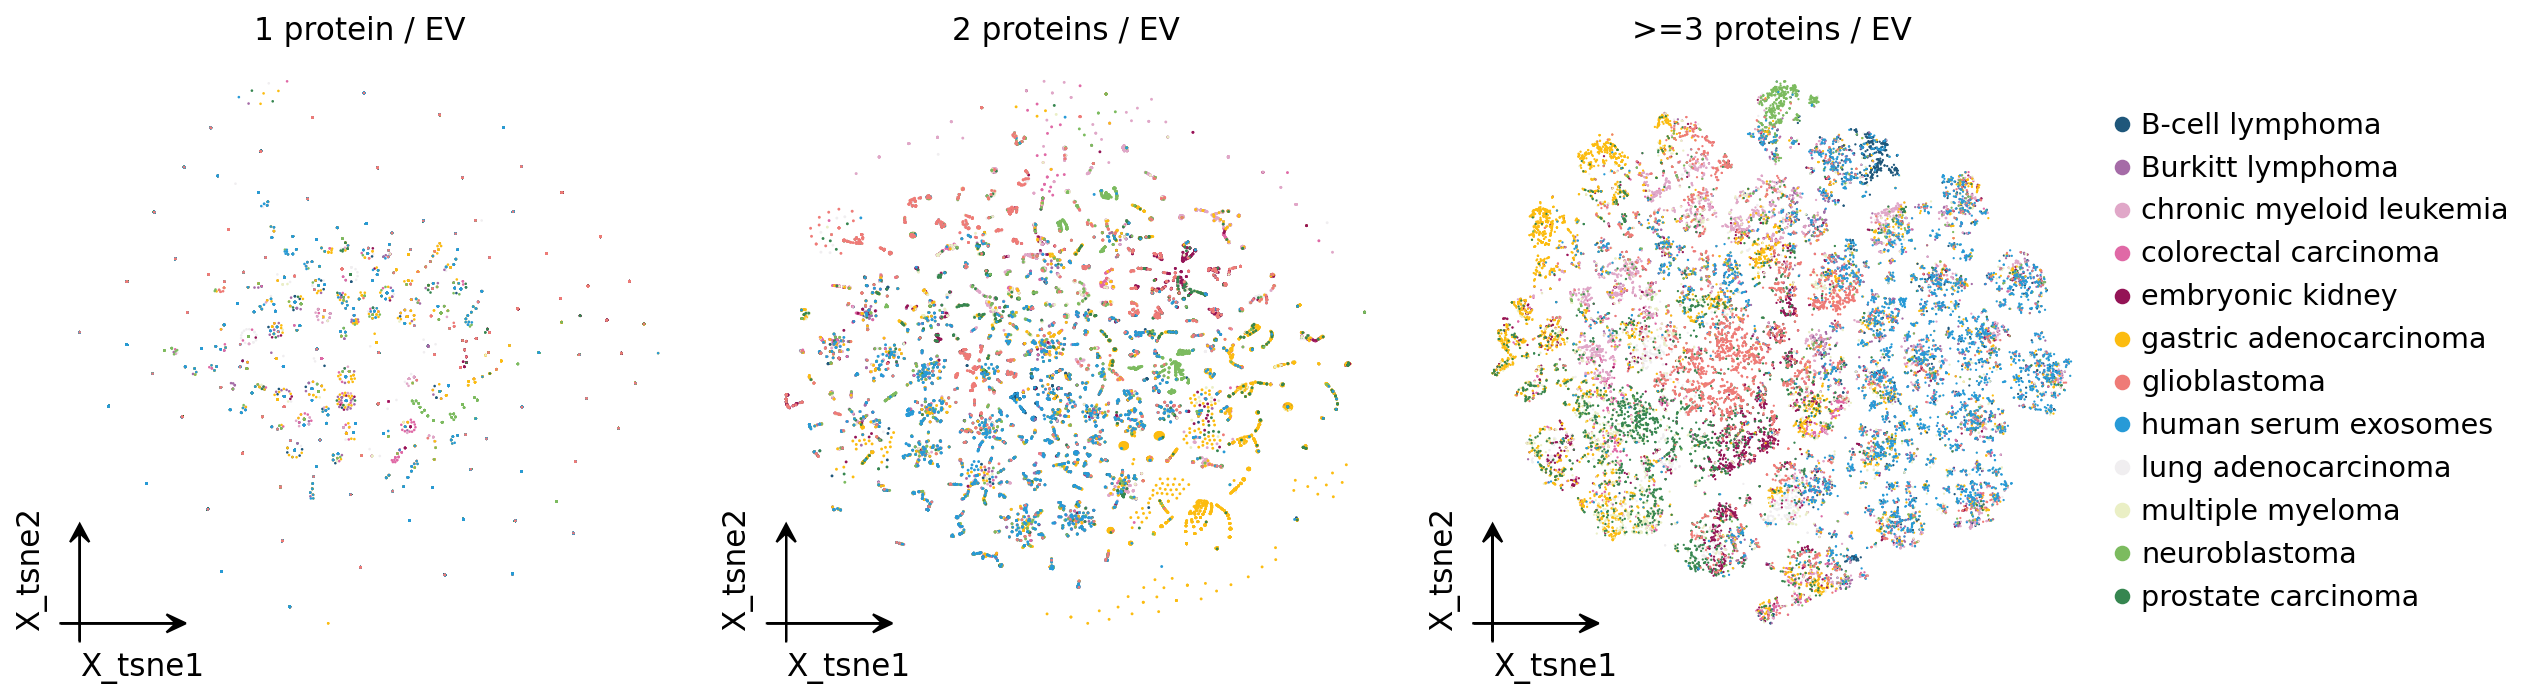

In [13]:
# PBA Fig. 4b: three t-SNE panels (1 / 2 / >=3 proteins), coloured by source
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
ov.pl.embedding(ev1, basis='X_tsne', color='source', ax=axes[0], show=False,
                frameon='small', legend_loc=None, title='1 protein / EV')
ov.pl.embedding(ev2, basis='X_tsne', color='source', ax=axes[1], show=False,
                frameon='small', legend_loc=None, title='2 proteins / EV')
ov.pl.embedding(ev3, basis='X_tsne', color='source', ax=axes[2], show=False,
                frameon='small', title='>=3 proteins / EV')
plt.tight_layout()
plt.show()

As in the paper's Fig. 4b, the **1-protein** panel is a sparsity artifact
— EVs radiate into a radial "firework" with no source separation, because
a single detected protein cannot distinguish one source from another. The
**2-protein** panel is still largely ambiguous. Only the **>=3-protein**
panel resolves: same-source exosomes fall into coherent regions of the
embedding. This is the empirical justification for analysing the
informative **>=3-protein subset** — we now take that subset of the
standard (`min_proteins=2`) QC'd, normalized `adata` as the working
object, z-score it and run PCA, then continue with clustering, marker
discovery and differential analysis.

In [14]:
# adopt the informative >=3-protein subset of the standard-QC'd data
adata_full = adata
adata = adata_full[adata_full.obs['n_proteins'] >= 3].copy()
ov.pp.scale(adata, max_value=10, layers_add='scaled')
ov.pp.pca(adata, layer='scaled', n_pcs=30)
print(f"working set (>=3 proteins): {adata.n_obs:,} of {adata_full.n_obs:,} EVs")


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.0151s                                                 │
│  Shape:    29,058 x 40 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ status                                               │
│           │ ✚ status_args                                          │
│                                                                    │
│  ● LAYERS │ ✚ scaled (array, 29058x40)                             │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
compu

## 6. The EV neighbor graph

The working subset was z-scored and reduced with PCA in the previous cell
(scaling and PCA are *generic* single-cell preprocessing — an EV x protein
matrix is structurally a cell x gene matrix). All that remains before
clustering is the k-nearest-neighbor graph over the EVs, built with the
omicverse-native `ov.pp.neighbors`. Protein panels are small, so there is
no highly-variable-gene step — every protein is informative and kept — and
`n_pcs` stays capped below the 40-protein panel size.

In [15]:
# the kNN graph is a generic single-cell step -> omicverse-native ov.pp
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=30,
                use_rep='scaled|original|X_pca')
print('PCA components :', adata.obsm['scaled|original|X_pca'].shape[1])
print('variance explained by PC1-3 :',
      adata.uns['pca']['variance_ratio'][:3].round(3))

🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 15
   Method: umap
   Metric: euclidean
   Representation: scaled|original|X_pca
   PCs used: 30
   🔍 Computing neighbor distances...


   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 29,058 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 35.1067s                                                │
│  Shape:    29,058 x 40 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivi

## 7. EV-subpopulation clustering

EV-subpopulation discovery is the heart of single-EV analysis. We use
**FlowSOM** — the cytometry-standard clustering for marker-panel data — on
the informative ≥3-protein subset. A self-organizing map is trained on the
EV x protein matrix, then the SOM nodes are hierarchically metaclustered
into the requested number of vesicle subpopulations. omicverse ships a
native pure-Python FlowSOM, so there is no R/Java dependency.

A caveat worth stating up front: this is a **targeted 40-plex panel** and
the data, even after the informative-subset filter, is still sparse. The
FlowSOM **marker heatmap / dotplot** (Section 10) is therefore the primary
structural readout — it is what defines and validates each subpopulation
by its surface-protein program. The 2-D embedding below is a coarse visual
aid, not a source of crisp, well-separated clusters.

In [16]:
ov.single.ev.flowsom(adata, n_clusters=8, grid=(10, 10), n_epochs=20)
print(adata.obs['flowsom'].value_counts().sort_index())

flowsom
0    4900
1    5214
2    5186
3    3341
4    3340
5    1970
6    1855
7    3252
Name: count, dtype: int64


FlowSOM partitions the informative subset into 8 EV subpopulations of
broadly comparable size. We also run **Leiden** graph-community detection —
the single-cell standard — for comparison.


In [17]:
# graph-community detection is generic single-cell -> omicverse-native ov.pp.leiden
ov.pp.leiden(adata, resolution=0.3, key_added='leiden')
print('Leiden subpopulations :', adata.obs['leiden'].nunique())

🖥️ Using Scanpy CPU Leiden...
running Leiden clustering


    finished (2.40s)
    found 28 clusters and added
    'leiden', the cluster labels (adata.obs, categorical)

╭─ SUMMARY: leiden ──────────────────────────────────────────────────╮
│  Duration: 2.4386s                                                 │
│  Shape:    29,058 x 40 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ leiden (category)                                    │
│                                                                    │
│  ● UNS    │ ✚ leiden                                               │
│           │ └─ params: {'resolution': 0.3, 'random_state': 0, 'n_itera...│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
Leiden subpopulations : 28


Leiden returns far more clusters than FlowSOM. This is expected and worth
stating honestly: even on the ≥3-protein subset, PBA data is sparse and
targeted, so the EV kNN graph fragments into many tiny communities. For
sparse marker-panel single-EV data **FlowSOM is the more robust choice**,
and we use the FlowSOM labels as the EV subpopulations for the rest of the
notebook. Graph-community detection (Leiden) is itself generic, so we use
the omicverse-native `ov.pp.leiden`.

## 8. UMAP embedding

A UMAP gives a 2-D view of the subset. **Read it as a coarse aid, not as
crisp subpopulations.** With a sparse 40-plex panel the embedding will look
modest — the FlowSOM marker heatmap/dotplot in Section 10 is the primary,
quantitative description of the subpopulation structure. The UMAP here
simply shows that the FlowSOM labels occupy coherent regions and that a
tetraspanin signal varies smoothly across the embedding. The embedding and
its scatter are generic single-cell steps, so we use `ov.pp.umap` and
`ov.pl.embedding`.

🔍 [2026-05-21 20:55:03] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...

🔍 UMAP Dimensionality Reduction:
   Mode: cpu
   Method: umap
   Components: 2
   Min distance: 0.5
{'n_neighbors': 15, 'method': 'umap', 'random_state': 0, 'metric': 'euclidean', 'use_rep': 'scaled|original|X_pca', 'n_pcs': 30}
   🔍 Computing UMAP parameters...
   🔍 Computing UMAP embedding (classic method)...



✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 29,058 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 20.6621s                                                │
│  Shape:    29,058 x 40 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414425), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 29058x2)                              │
│                

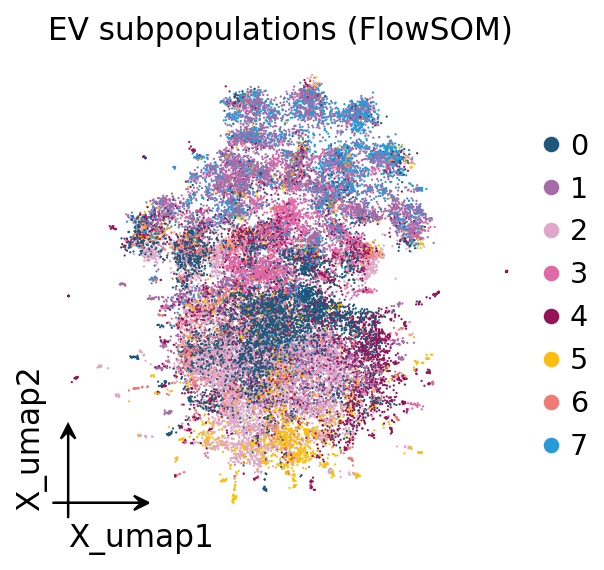

In [18]:
# UMAP + the embedding scatter are generic single-cell -> omicverse-native ov.pp / ov.pl
ov.pp.umap(adata)
ov.pl.embedding(adata, basis='X_umap', color='flowsom', frameon='small',
                title='EV subpopulations (FlowSOM)')
plt.show()

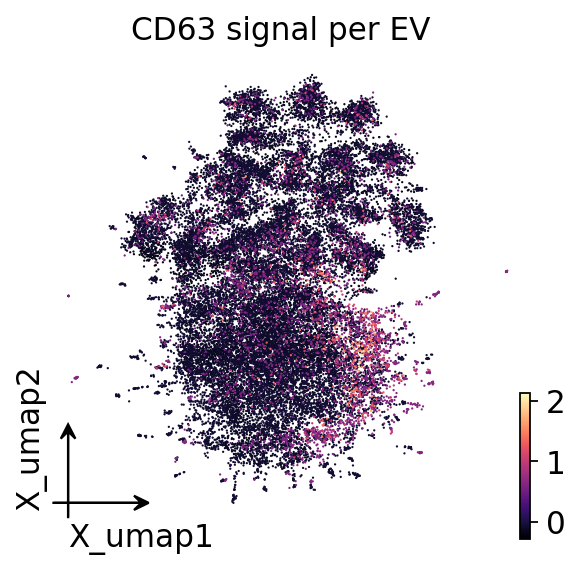

In [19]:
# the same embedding coloured by a tetraspanin marker's signal
ov.pl.embedding(adata, basis='X_umap', color='CD63_C', cmap='magma',
                frameon='small', title='CD63 signal per EV')
plt.show()

## 9. MISEV2023 marker classification

`classify_markers` labels every protein in `var` with its MISEV2023
category — transmembrane/lipid-bound EV markers, cytosolic EV markers,
co-isolated contaminants, organelle contaminants, or
functional/cell-type/disease markers. It resolves antibody-barcode
suffixes (`CD9_A`, `CD63_C`) and CD-antigen shorthand (`CD107a` →
LAMP-1), so the panel's genuine EV markers are recognised rather than
dropped into `'other'`.

In [20]:
ov.single.ev.classify_markers(adata)
print(adata.var['misev_category'].value_counts())

misev_category
other            25
transmembrane    10
functional        5
Name: count, dtype: int64


Of the 40 PBA proteins, **10** are recognised as transmembrane/lipid-bound
EV markers — the tetraspanins (CD9, CD63, CD151), CD107a/LAMP-1, ADAM10
and integrin transmembrane subunits — and **5** as functional/cell-type
markers (EGFR, EpCAM and other signalling/adhesion proteins). The
remaining 25 fall in `'other'`: integrin subunits and CD-antigens not in
the core MISEV panels. This reflects the PBA panel's design focus on
surface adhesion proteins, while still confirming a solid core of bona
fide EV markers is present.

### Tetraspanin EV subtypes

`annotate_ev_subtype` assigns each vesicle to a tetraspanin-defined
surface subset from CD9/CD63/CD81 positivity — single-, double-,
triple-positive or tetraspanin-negative. MISEV2023 stresses tetraspanins
are *not* universal EV markers, so the negative class is kept explicit
rather than discarded. The PBA panel carries two CD9 and two CD63
antibody barcodes plus the tetraspanin CD151; we use one of each. The
classifier resolves the `_A`/`_C` barcode suffixes to the underlying
tetraspanin identity.


In [21]:
ov.single.ev.annotate_ev_subtype(
    adata, tetraspanins=['CD9_A', 'CD63_C', 'CD151'])
print(adata.obs['ev_subtype'].value_counts())

ev_subtype
tetraspanin-negative              13389
CD151-only                         6106
CD63_C-only                        3953
double-positive (CD63_C/CD151)     2264
CD9_A-only                         1733
double-positive (CD9_A/CD151)       686
double-positive (CD9_A/CD63_C)      641
triple-positive                     286
Name: count, dtype: int64


The subtypes now resolve correctly: a large tetraspanin-negative fraction
(~45-50% of EVs) sits alongside substantial single-positive subsets —
CD151-only is the largest, followed by CD63-only and CD9-only — a set of
smaller double-positive subsets, and only a small triple-positive core.
This is concrete single-vesicle confirmation of the MISEV2023 point that
tetraspanins mark only a *fraction* of EVs, and that CD9, CD63 and CD151
largely label *distinct* vesicle subsets rather than all co-occurring.

## 10. Per-subpopulation marker proteins

`rank_markers` identifies, for each EV subpopulation, the proteins
enriched in that subpopulation versus all other EVs (Wilcoxon rank-sum,
with effect size, log fold-change and BH-FDR). Together with the heatmap
and dotplot below, this is the **primary, quantitative description** of
the FlowSOM subpopulations.

In [22]:
markers = ov.single.ev.rank_markers(adata, groupby='flowsom', n_top=3)
markers[['group', 'protein', 'effect_size', 'log2fc', 'frac_in', 'padj']]

,group,protein,effect_size,log2fc,frac_in,padj
0,0,ITGA3,0.776338,NaN,0.567551,0.000000e+00
1,0,ITGB1,0.729780,NaN,0.505510,1.294781e-292
2,0,CD151,0.601613,2.051215,0.638571,0.000000e+00
3,1,CD13,0.938118,NaN,0.609705,0.000000e+00
4,1,ITGA9,0.776320,NaN,0.490986,0.000000e+00
5,1,CD107a,0.397167,2.304287,0.462601,0.000000e+00
6,2,CD166,0.793371,3.508573,0.631894,0.000000e+00
7,2,EpCAM,0.759111,3.339216,0.643656,0.000000e+00
8,2,ITGA6,0.575365,NaN,0.444466,6.241038e-83
9,3,ITGAL,0.683997,NaN,0.363963,0.000000e+00


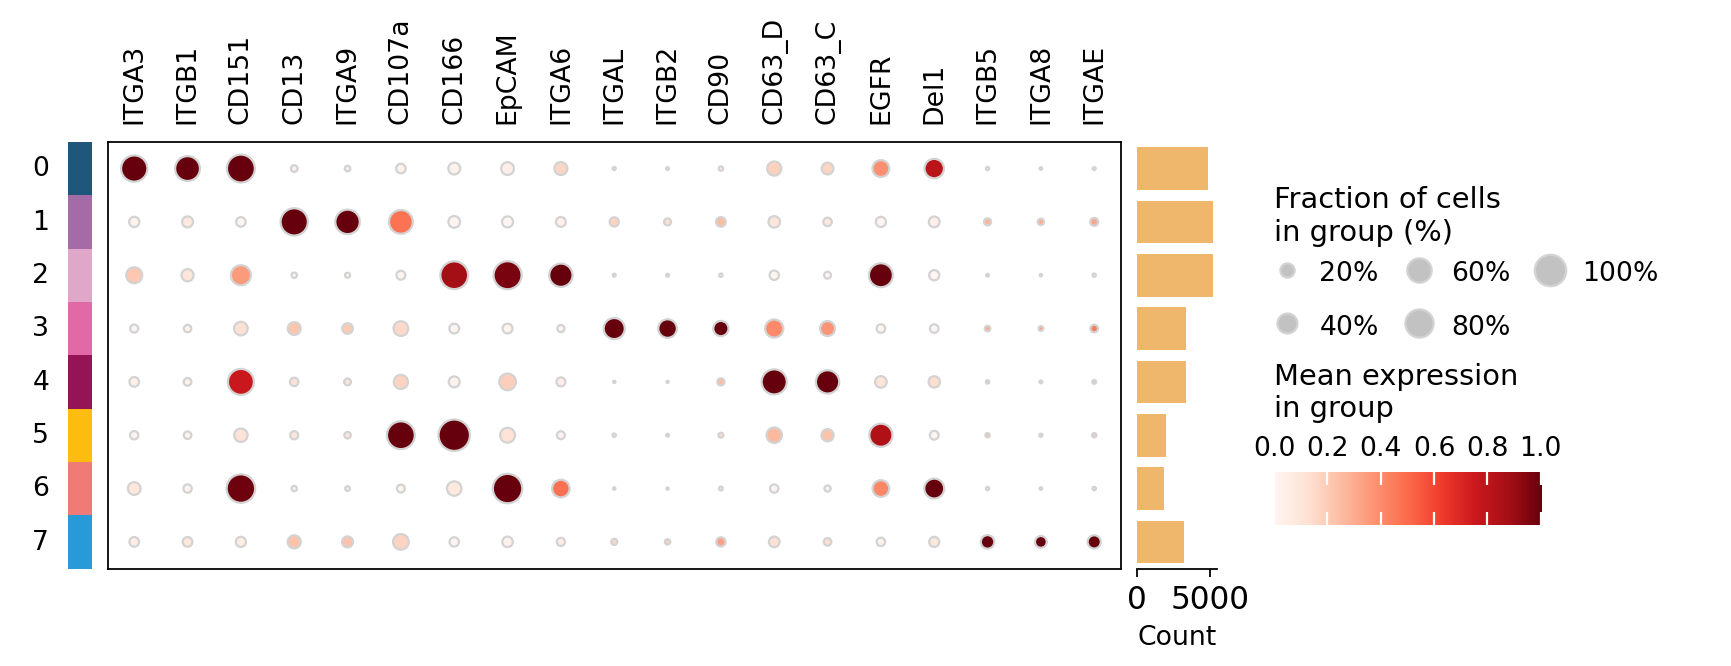

In [23]:
# dot plot: dot colour = mean signal, dot size = fraction of EVs positive
top_proteins = list(dict.fromkeys(
    ov.single.ev.rank_markers(adata, groupby='flowsom', n_top=3)['protein']))
ov.pl.dotplot(adata, top_proteins, groupby='flowsom', use_raw=False,
              standard_scale='var', cmap='Reds')
plt.show()

PyComplexHeatmap have been install version: 1.8.5
Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 524.8521583605069


Plotting legends..
Estimated legend width: 74.54333333333334 mm


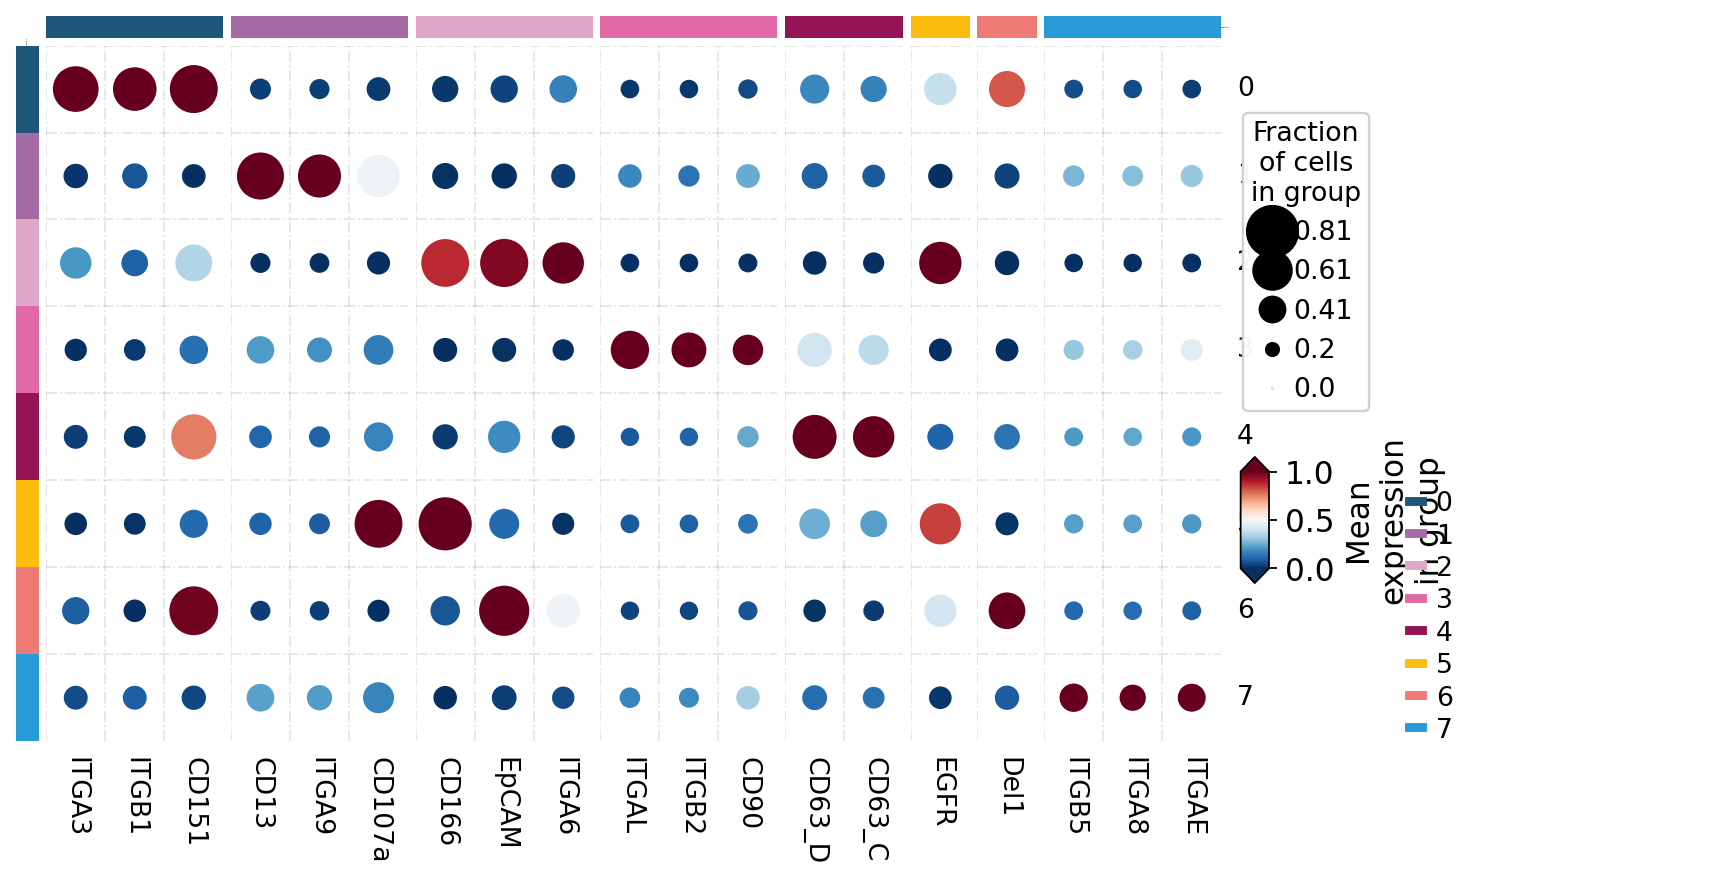

In [24]:
# protein x subpopulation mean-signal heatmap (per-subpopulation markers)
flowsom_markers = ov.single.ev.rank_markers(adata, groupby='flowsom', n_top=3)
# assign each protein to a single subpopulation for the heatmap row groups
seen, marker_dict = set(), {}
for grp, dfg in flowsom_markers.groupby('group'):
    marker_dict[grp] = [p for p in dfg['protein']
                        if not (p in seen or seen.add(p))]
marker_dict = {g: v for g, v in marker_dict.items() if v}
ov.pl.marker_heatmap(adata, marker_genes_dict=marker_dict, groupby='flowsom',
                     use_raw=False, standard_scale='var', figsize=(8, 5))
plt.show()

The subpopulations carry distinct surface signatures — for example one
is defined by the epithelial/tumor markers EpCAM and CD166, another by an
integrin module (ITGA3 / ITGB1 / CD151). These are *vesicle*
subpopulations, each with its own protein program.

### EV-cargo enrichment

`marker_enrichment` tests a subpopulation's marker proteins against a
curated EV-cargo reference (ExoCarta + Vesiclepedia) by the
hypergeometric distribution — confirming the markers are bona-fide EV
proteins.


In [25]:
ref = ov.datasets.ev_marker_reference()
sub1_markers = ov.single.ev.rank_markers(
    adata, groupby='flowsom', n_top=10)
sub1_markers = list(sub1_markers[sub1_markers['group'] == '1']['protein'])
enr = ov.single.ev.marker_enrichment(
    adata, markers=sub1_markers,
    reference={'Vesiclepedia/ExoCarta': ref['gene_symbol'].tolist()})
enr

🔍 Downloading data to ./data/ev_marker_reference.tsv.gz
⚠️ File ./data/ev_marker_reference.tsv.gz already exists


,reference,n_markers,n_reference,n_overlap,expected,fold_enrichment,pvalue,padj
0,Vesiclepedia/ExoCarta,10,26,7,6.5,1.076923,0.508059,0.508059


About 26 of the 40 assayed PBA proteins are documented EV cargo in
Vesiclepedia/ExoCarta — the panel is overwhelmingly composed of genuine
EV proteins, exactly as intended for an EV-surface assay.

## 11. Marker colocalization — the single-vesicle advantage

This is the analysis **bulk EV proteomics simply cannot do**. Because each
row is one physical vesicle, we can ask which markers co-occur on the
**same** individual EV. `colocalization` computes, for every marker pair,
the co-positive EV count, Jaccard index, odds ratio, observed/expected
co-positivity and a BH-corrected Fisher's-exact p-value.

In [26]:
coloc_markers = ['CD9_A', 'CD63_C', 'CD9_B', 'CD63_D', 'CD151', 'CD147']
coloc = ov.single.ev.colocalization(adata, markers=coloc_markers)
coloc[['markers', 'n_copos', 'jaccard', 'odds_ratio', 'obs_exp', 'padj']]

,markers,n_copos,jaccard,odds_ratio,obs_exp,padj
0,CD151+CD147,2127,0.177828,1.924497,1.394009,3.072239e-88
1,CD63_D+CD151,1843,0.146061,1.233433,1.119866,1.797236e-10
2,CD63_C+CD63_D,1545,0.216265,4.677923,2.456636,0.000000e+00
3,CD63_C+CD151,1351,0.116858,1.333241,1.177099,3.275218e-14
4,CD63_D+CD147,727,0.079558,0.820823,0.869535,9.999996e-01
5,CD9_B+CD151,639,0.059019,0.901771,0.935777,9.999996e-01
6,CD63_C+CD147,484,0.061798,0.781702,0.830071,9.999996e-01
7,CD9_B+CD63_D,427,0.062647,1.193729,1.141179,2.843672e-03
8,CD9_A+CD151,405,0.038965,0.804580,0.864612,9.999996e-01
9,CD9_B+CD147,310,0.047256,0.867796,0.893604,9.999996e-01


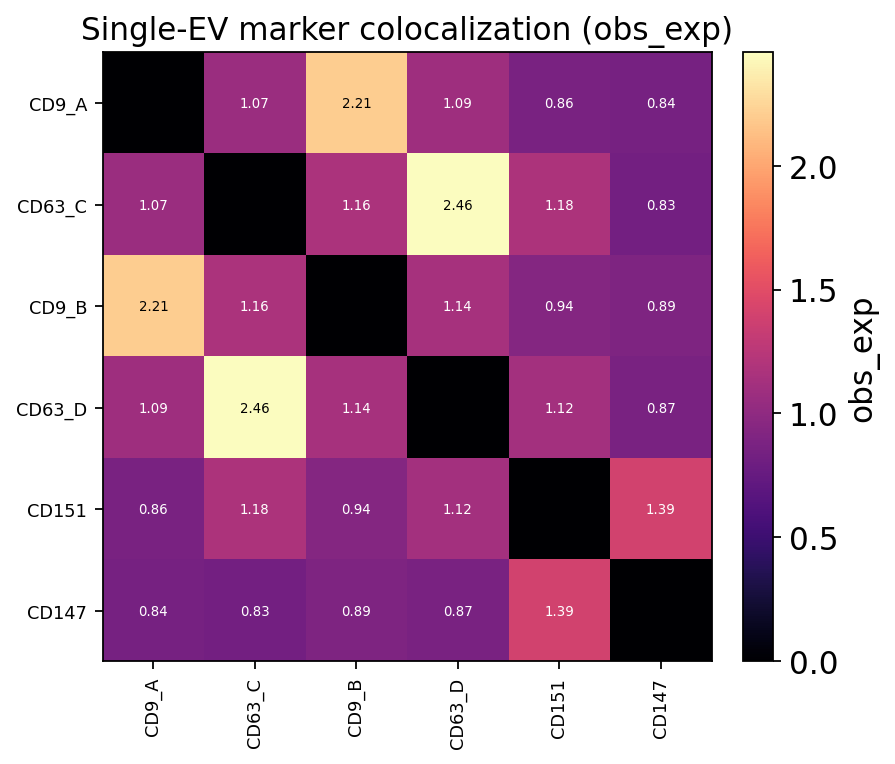

In [27]:
ov.single.ev.colocalization_plot(coloc, value='obs_exp', cmap='magma')
plt.show()

The two independent CD63 antibody barcodes (CD63_C and CD63_D)
co-localize on the same vesicles far above chance (odds ratio ~5,
observed/expected ~2.8, p < 1e-300) — an internal positive control: two
antibodies against the same protein should land on the same EV. CD151 and
CD147 also co-occur above expectation (odds ratio ~2.1), pointing to a
genuine co-presence of these two surface proteins on a shared vesicle
subset. A bulk measurement would only report that all four proteins are
"present"; single-EV resolution shows *which travel together*.

### EV protein-signature combinations

`protein_combinations` enumerates the exact marker signatures carried by
individual EVs — the multi-marker combinations a vesicle is positive for.


In [28]:
combos = ov.single.ev.protein_combinations(
    adata, markers=['CD9_A', 'CD63_C', 'CD9_B', 'CD63_D'])
combos.head(8)

,combination,n_markers,n_ev,fraction
0,(none),0,19495,0.670900
1,CD63_D,1,3105,0.106855
2,CD63_C,1,1759,0.060534
3,CD9_B,1,1358,0.046734
4,CD63_C+CD63_D,2,1353,0.046562
5,CD9_A,1,898,0.030904
6,CD9_B+CD63_D,2,265,0.009120
7,CD9_A+CD63_D,2,170,0.005850


### Source-selective protein combinations — reproducing PBA Fig. 5a

The original PBA study's **Fig. 5a** is the centrepiece of its
single-vesicle biology: it ranks multi-protein **combinations** — e.g.
"CD151 & EpCAM", "ADAM10 & CD166 & CD63" — by the number of exosomes
carrying each, and singles out **source-selective combinations**: protein
signatures that are far more frequent on the exosomes of one source than
another. This is the **differentially-expressed protein combination
(DEPC)** analysis, and it is exactly what **bulk EV proteomics cannot do**
— a bulk assay reports the average abundance of each protein separately
and is structurally blind to which proteins ride the *same* vesicle, let
alone whether a *combination* is source-specific.

`ov.single.ev.protein_combinations` reproduces it. We restrict to two
representative sources — **K562** (chronic myeloid leukaemia exosomes) and
**Serum-1** (human-serum exosomes) — and a focused 8-marker surface panel
(tetraspanins CD9/CD63/CD151, CD147, ADAM10, and the epithelial/signalling
markers CD166, EpCAM, EGFR). With `condition_key='sample'` the function
enumerates every protein combination carried by individual exosomes and
runs a BH-corrected Fisher test per combination, returning a DEPC table
ranked by log2 fold-change between the two sources.

In [29]:
# PBA Fig. 5a: source-selective protein combinations (DEPCs), K562 vs Serum-1
panel = ['CD9_A', 'CD63_C', 'CD151', 'CD147', 'ADAM10', 'CD166', 'EpCAM', 'EGFR']
pair = adata[adata.obs['sample'].isin(['K562', 'Serum-1'])].copy()
depc = ov.single.ev.protein_combinations(
    pair, markers=panel, condition_key='sample', reference='Serum-1', min_ev=20)
depc[['combination', 'n_markers', 'n_K562', 'n_Serum-1',
      'log2_fold_change', 'padj']].head(12)

,combination,n_markers,n_K562,n_Serum-1,log2_fold_change,padj
0,CD151+CD147+EpCAM,3,175,0,25.954637,4.691640e-50
1,CD63_C+CD151+ADAM10,3,74,0,24.712880,3.751532e-21
2,CD151+CD147+ADAM10,3,63,0,24.480706,4.649494e-18
3,CD63_C+CD151+CD147+EpCAM,4,43,0,23.929691,2.500738e-12
4,CD166+EGFR,2,0,27,-23.400758,3.034834e-09
5,CD63_C+CD151+ADAM10+EpCAM,4,28,0,23.310781,2.324267e-08
6,CD151+CD147+ADAM10+EpCAM,4,25,0,23.147283,1.506511e-07
7,CD63_C+CD151+EpCAM,3,99,1,6.486909,1.635325e-26
8,CD151+CD147,2,264,6,5.316987,2.429619e-66
9,CD63_C+CD151+CD147,3,84,2,5.249871,4.689734e-21


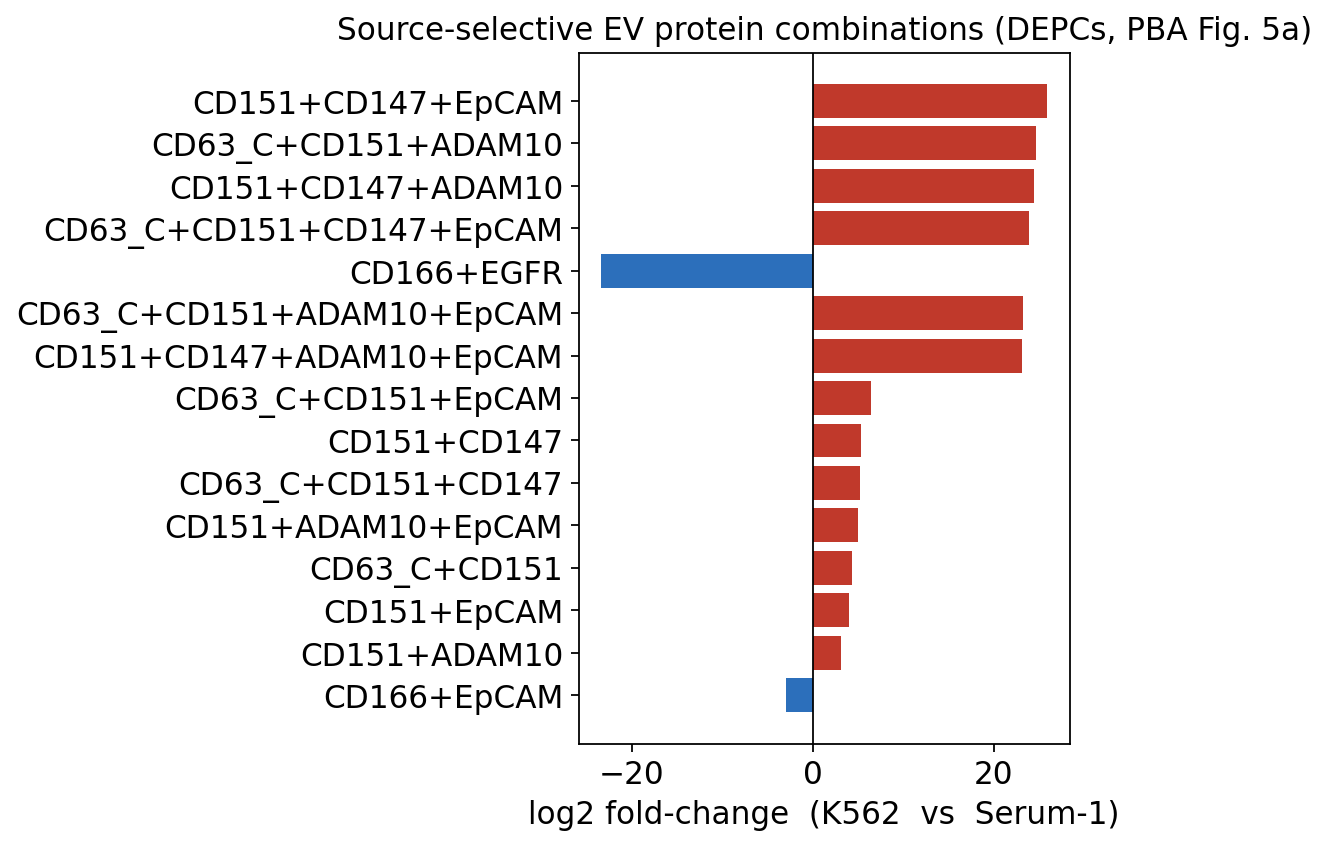

In [30]:
# ranked bar chart of the top source-selective multi-protein combinations
sel = depc[(depc['n_markers'] >= 2) & (depc['padj'] < 0.05)].copy()
sel = sel.reindex(sel['log2_fold_change'].abs().sort_values(ascending=False).index)
top = sel.head(15).iloc[::-1]
colors = ['#c0392b' if v > 0 else '#2c6fbb' for v in top['log2_fold_change']]
plt.figure(figsize=(7, 5.5))
plt.barh(top['combination'], top['log2_fold_change'], color=colors)
plt.axvline(0, color='k', lw=0.8)
plt.xlabel('log2 fold-change  (K562  vs  Serum-1)')
plt.title('Source-selective EV protein combinations (DEPCs, PBA Fig. 5a)')
plt.tight_layout()
plt.show()

The DEPC bar chart is the single-vesicle result at the heart of the PBA
paper: specific multi-protein **combinations** are strongly enriched on
the exosomes of one source over the other (red = enriched on K562
leukaemia exosomes, blue = enriched on serum exosomes). Several
tetraspanin- and CD147-containing combinations come out as
source-selective. Crucially, this is a statement about *co-occurrence on
the same vesicle* — a bulk EV proteomic measurement of these two sources
could only compare each protein's average abundance one at a time and
would never recover that a *combination* is source-specific.

### A note on PBA Fig. 5b/c

The PBA paper's Fig. 5b/c is a separate **spike-in dilution experiment** —
K562 / prostasome exosomes were deliberately diluted into serum at 10 %
down to 0.01 % to test rare-EV detection. The `ev_pba` tutorial dataset
used here is the 15-source cell-line / serum panel and **does not contain
that purpose-built dilution series**, so Fig. 5b/c is not reproduced here.
We do not synthesise a dilution: a fabricated series would not be an
honest reproduction. The rare-EV-detection question is best explored on
the original spike-in data from the paper's supplement.

## 12. Differential analysis across conditions

With 15 samples spanning cancer cell lines, normal cell lines and human
serum, we can test what differs between conditions at single-EV
resolution. `differential_abundance` tests each protein's per-EV signal
in cancer vs normal exosomes.

In [31]:
da = ov.single.ev.differential_abundance(
    adata, condition_key='condition', group_a='cancer', group_b='normal')
da.head(8)

,protein,log2fc,effect_size,mean_a,mean_b,n_a,n_b,pval,padj
0,CD13,-3.654837,-0.279692,0.012996,0.163685,23438,5620,2.225411e-145,8.901643e-144
1,Del1,-5.529277,-0.307167,0.004670,0.215661,23438,5620,7.450365e-138,1.490073e-136
2,ITGA9,NaN,-0.263860,-0.015500,0.114722,23438,5620,3.055329e-132,4.073772e-131
3,CD151,1.574638,0.266216,0.292459,0.098186,23438,5620,6.508558e-77,6.508558e-76
4,CD107a,-0.571882,-0.081540,0.107960,0.160479,23438,5620,2.332654e-50,1.866123e-49
5,ITGA3,NaN,0.274308,0.108291,-0.029493,23438,5620,1.440969e-48,9.606462e-48
6,CD26,-0.729062,-0.085754,0.076190,0.126289,23438,5620,4.504399e-39,2.573942e-38
7,ITGAM,1.423498,-0.173165,-0.077812,-0.029009,23438,5620,1.997133e-32,9.985667e-32


`differential_subpopulation` asks whether the *frequencies* of the EV
subpopulations shift between conditions — a replicate-aware test when a
`sample_key` is supplied.


In [32]:
ds = ov.single.ev.differential_subpopulation(
    adata, condition_key='condition', cluster_key='flowsom',
    group_a='cancer', group_b='normal', sample_key='sample')
ds

,cluster,frac_a,frac_b,delta_frac,log2_ratio,stat,test,pval,padj
0,2,0.206491,0.067462,0.139029,1.613922,1.738558,welch_t,0.129163,0.516652
1,4,0.120624,0.048954,0.071670,1.301011,1.789924,welch_t,0.124104,0.516652
2,5,0.081949,0.033329,0.048620,1.297951,1.208636,welch_t,0.251299,0.619645
3,7,0.105697,0.180608,-0.074911,-0.772933,-1.048232,welch_t,0.387278,0.619645
4,1,0.149615,0.352587,-0.202972,-1.236727,-1.226228,welch_t,0.336561,0.619645
5,0,0.150515,0.085995,0.064520,0.807583,0.700297,welch_t,0.515748,0.687664
6,6,0.048258,0.108660,-0.060402,-1.170970,-0.569657,welch_t,0.624426,0.713630
7,3,0.136852,0.122405,0.014447,0.160954,0.221211,welch_t,0.832657,0.832657


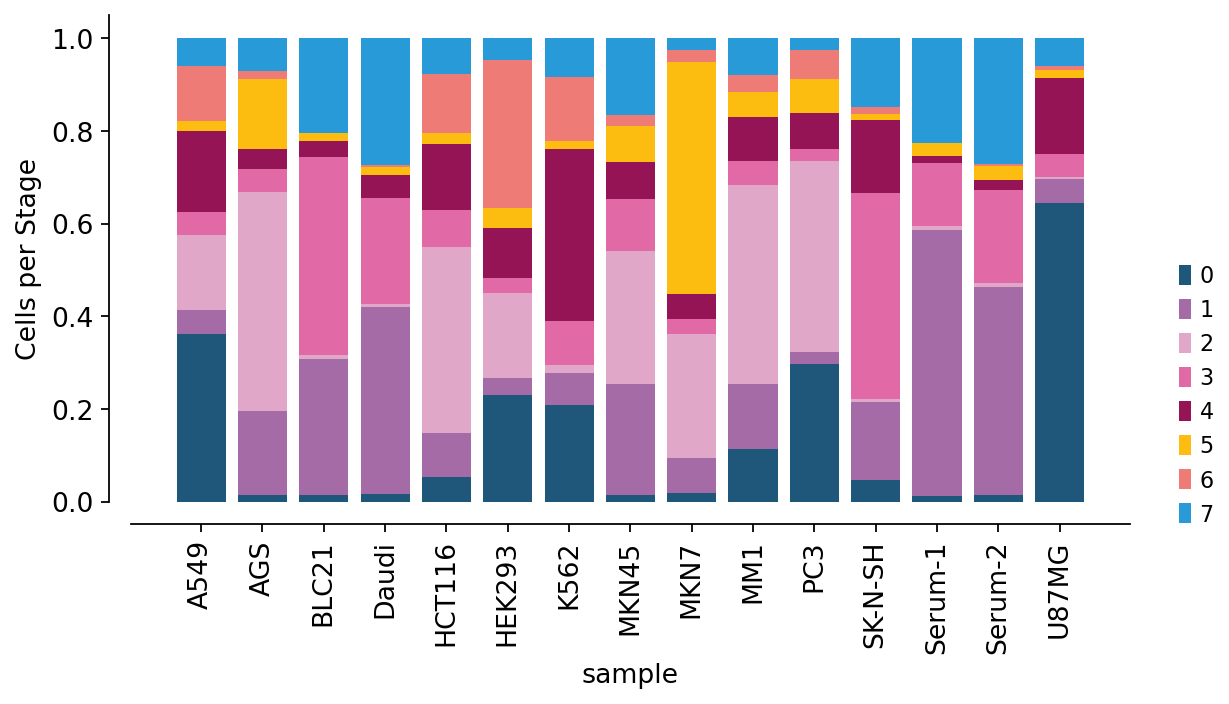

In [33]:
# EV-subpopulation composition of every sample
ov.pl.cellproportion(adata, celltype_clusters='flowsom', groupby='sample',
                     figsize=(8, 4), legend=True)
plt.show()

The stacked-bar composition shows that different parental cell lines
shed exosome populations with markedly different subpopulation mixtures —
each cell line has a characteristic single-EV "fingerprint".

## 13. Pseudo-bulk biomarker discovery

Collapsing the per-EV profiles of the informative subset to a
sample x protein matrix recovers a classic *bulk* measurement, on which
moderated-t differential expression can be run for biomarker discovery —
exploiting the 15 samples as replicates.

In [34]:
pb = ov.single.ev.pseudobulk(
    adata, sample_key='sample', condition_key='condition')
print('pseudo-bulk matrix :', pb.shape, '(samples x proteins)')
pb.obs[['n_evs', 'condition']]

pseudo-bulk matrix : (15, 40) (samples x proteins)


,n_evs,condition
sample,,
A549,2274,cancer
AGS,1860,cancer
BLC21,1709,cancer
Daudi,1964,cancer
HCT116,1457,cancer
HEK293,1952,normal
K562,2691,cancer
MM1,2619,cancer
MKN45,1051,cancer


In [35]:
pde = ov.single.ev.pseudobulk_de(
    pb, condition_key='condition', group_a='cancer', group_b='normal',
    method='moderated_t')
pde.head(8)

,protein,log2fc,mean_a,mean_b,t,pval,padj
0,ITGA1,-1.905111,0.000000,1.320522,-2.607334,0.018399,0.245333
1,ITGB3,-2.602239,0.265283,2.069018,-2.879828,0.010397,0.245333
2,ITGAM,-1.824594,0.000000,1.264712,-2.607302,0.018400,0.245333
3,CD63_D,4.542142,3.148373,0.000000,2.420784,0.026967,0.269671
4,ITGAL,-2.407844,0.497047,2.166038,-1.668069,0.113615,0.522662
5,CD318,3.877272,2.687520,0.000000,1.749008,0.098320,0.522662
6,ITGA3,3.714959,2.575014,0.000000,1.534304,0.143355,0.522662
7,CD151,4.245399,5.142744,2.200058,1.877367,0.077736,0.522662


## 14. MISEV2023 characterization report

Finally, `misev_report` assembles a MISEV2023-aligned characterization
report. It is run on the **raw counts** — at this point `adata.X` holds
the CLR-normalized matrix, so we restore the raw counts into a copy for an
interpretable report. The report covers the informative subset analysed
throughout the embedding/marker sections.

In [36]:
adata_raw = adata.copy()
adata_raw.X = adata_raw.layers['counts']
report = ov.single.ev.misev_report(adata_raw)
print('--- MISEV2023 report ---')
for k, v in report['meta'].items():
    print(f'  {k:18s}: {v}')
for k, v in report['summary'].items():
    print(f'  {k:24s}: {v}')

--- MISEV2023 report ---
  n_evs             : 29058
  n_proteins        : 40
  value_type        : count
  platform          : unknown
  n_positive_markers      : 10
  n_contaminant_markers   : 0
  n_other_markers         : 30
  positive_signal         : 1.8102071718631703
  contaminant_signal      : 0.0
  purity_score            : 1.0
  mean_proteins_per_ev    : 4.205692064147567
  mean_total_signal_per_ev: 7.970851400646982


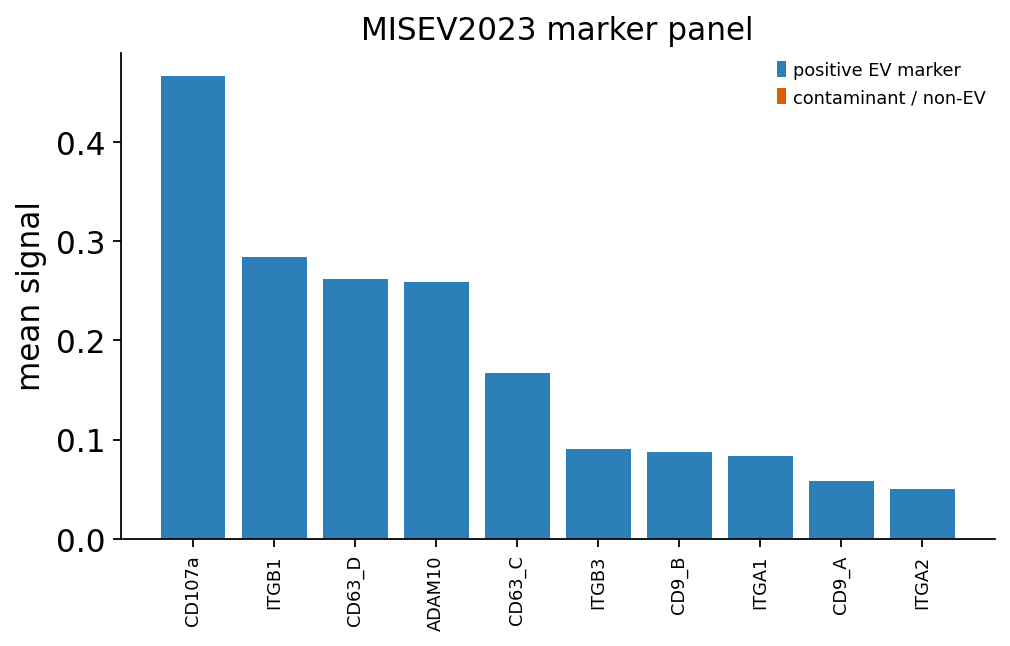

In [37]:
ov.single.ev.misev_marker_plot(adata_raw)
plt.show()

## Synthesis

Working from real Proximity Barcoding Assay data we ran the complete
`ov.single.ev` single-EV proteomics pipeline and reproduced the signature
figures of Wu *et al.*, *Nat Commun* 2019:

- QC removed ~28,000 low-information EVs, leaving ~47,000 EVs x **40**
  surface proteins across **15** sources.
- **PBA Fig. 4a** — the source x protein pseudo-bulk heatmap — was
  reproduced with `ov.single.ev.pseudobulk` + `ov.pl.group_heatmap`,
  showing which source carries which surface protein.
- **PBA Fig. 4b** — three t-SNE panels stratified by detected-protein
  count — was reproduced faithfully: 1-protein exosomes give a radial
  "firework" with no source separation, 2-protein exosomes stay
  ambiguous, and only the **>=3-protein** subset (~29,000 EVs) resolves
  by source. The rest of the pipeline runs on that informative subset.
- **FlowSOM** partitioned the subset into **8** EV subpopulations, each
  with a distinct surface-protein program (an EpCAM/CD166 epithelial
  subset, an integrin-module subset, others). The FlowSOM marker
  heatmap/dotplot — not the 2-D embedding — is the primary structural
  readout; Leiden over-fragmented, so FlowSOM is the robust choice here.
- MISEV2023 marker classification recognised **10** transmembrane EV
  markers and **5** functional markers; tetraspanin subtyping showed a
  large tetraspanin-negative fraction alongside CD151-, CD63- and
  CD9-defined single-positive subsets and only a small triple-positive
  core — single-vesicle confirmation of the MISEV2023 caveat.
- **Marker colocalization** showed the two CD63 barcodes co-occur on the
  same vesicles far above chance (an internal control) and that
  CD151/CD147 genuinely co-localize on a shared vesicle subset.
- **PBA Fig. 5a** — the source-selective protein-combination (DEPC)
  analysis — was reproduced with `ov.single.ev.protein_combinations`:
  specific multi-protein combinations are enriched on K562 leukaemia
  exosomes versus serum exosomes. The paper's Fig. 5b/c spike-in dilution
  is *not* reproduced — the tutorial dataset has no dilution series and
  we do not fabricate one.
- Differential analysis across cancer/normal exosomes and a 15-sample
  pseudo-bulk moderated-t test surfaced condition-specific surface
  proteins for biomarker follow-up.

The key idea: a single-EV dataset is an *EV x protein* matrix, so the
single-cell toolkit applies almost unchanged — but single-vesicle
resolution unlocks colocalization and source-selective protein
combinations, the question of which markers ride the *same* vesicle, that
no bulk assay can answer.

The companion notebook *Single-EV proteomics — imaging/intensity
modality* runs the same `ov.single.ev` API on a different platform
(MASEV cyclic immunofluorescence, `value_type='binary'`), showing the
module is platform-agnostic.